# Principal Component Analysis

it is a feature extraction technique, which helps in reducing curse of dimensionality
It converts a high dimensional data set into a  lower dimension

## Benefits of using PCA:-
    1. Faster execution of ML Algorithms
    2. Visualizations

# Applying PCA from scratch

In [1]:
# creating dummy data
import numpy as np
import pandas as pd

np.random.seed(23) 

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])

df1['target'] = 0

df = pd.concat([df, df1], ignore_index=True)


df = df.sample(40)

In [2]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


In [3]:
pip install -U nbformat



[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import plotly.express as px

fig = px.scatter_3d(df,x='feature1',y='feature2',z='feature3',color='target')

fig.update_traces(marker=dict(size=5,line=dict(width=2,color='DarkSlateGrey')),selector=dict(mode='markers'))

fig.show()

In [6]:
# step1: apply standard scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df.iloc[:,:3] = scaler.fit_transform(df.iloc[:,:3])


In [8]:
# step2 : find covariance matrix
covariance_matrix = np.cov(df.iloc[:,:3].T)
print("Covariance matrix:\n", covariance_matrix)


Covariance matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [15]:
# step3: find eigen values and eigen vectors
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [16]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [17]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


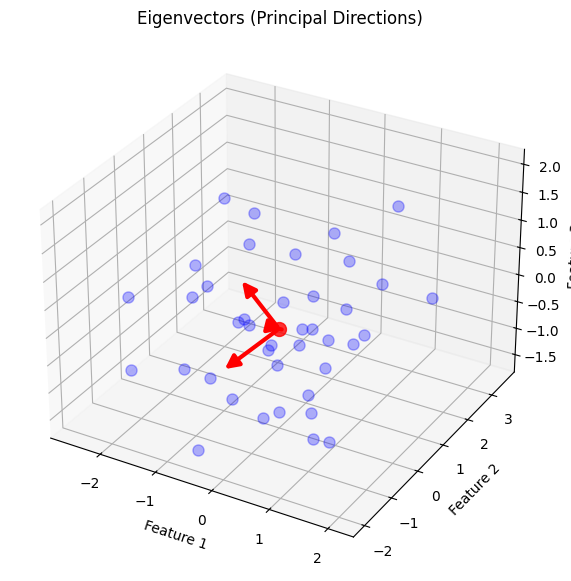

In [20]:
%pylab inline

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D, proj3d
from matplotlib.patches import FancyArrowPatch
import numpy as np

# compute eigenvectors if not defined
features = df[['feature1', 'feature2', 'feature3']]
cov_mat = np.cov(features.values.T)
eigen_values, eigen_vectors = np.linalg.eig(cov_mat)

# fixed Arrow3D class (works across matplotlib versions)
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0, 0), (0, 0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d

        # ✅ compatible way to get projection matrix
        try:
            M = self.axes.M  # for matplotlib >=3.7
        except AttributeError:
            M = renderer.M   # for older versions

        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return np.min(zs)

# plot data
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(df['feature1'], df['feature2'], df['feature3'], 'o', markersize=8, color='blue', alpha=0.3)
mean_vec = features.mean().values
ax.plot([mean_vec[0]], [mean_vec[1]], [mean_vec[2]], 'o', markersize=10, color='red', alpha=0.8)

# draw eigenvectors
for i in range(len(eigen_vectors)):
    v = eigen_vectors[:, i] * np.sqrt(eigen_values[i])
    a = Arrow3D(
        [mean_vec[0], mean_vec[0] + v[0]],
        [mean_vec[1], mean_vec[1] + v[1]],
        [mean_vec[2], mean_vec[2] + v[2]],
        mutation_scale=20,
        lw=3,
        arrowstyle="-|>",
        color="r"
    )
    ax.add_artist(a)

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')
plt.title('Eigenvectors (Principal Directions)')
plt.show()


In [22]:
pc = eigen_vectors[0:2]
pc

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442]])

In [23]:
trf_df = np.dot(df.iloc[:,:3], pc.T)

new_df = pd.DataFrame(data = trf_df, columns = ['PC1', 'PC2'])
new_df['target'] = df['target']

new_df.head()


,PC1,PC2,target
0,0.599433,1.795862,1
1,1.056919,-0.212737,1
2,-0.271876,0.498222,1
3,-0.621586,0.023110,1
4,1.567286,1.730967,1


In [24]:

new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()